# 👟 Laboratorio 02.4: Pronóstico de Pasos y Carga de Actividad
### Proyección de Pasos Diarios (`total_steps`) y Ratio de Carga Aguda:Crónica (`acwr_steps`)

---

## 🎯 Objetivo
1. **Pronosticar Pasos Diarios**: Modelar el volumen de locomoción sin permitir valores negativos ($	ext{floor} = 0$).
2. **Monitorizar el ACWR**: Evitar picos de sobreentrenamiento (zona de riesgo cuando $	ext{ACWR} > 1.5$).


In [1]:
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.analytics.time_series_models import (
    compute_physiological_bounds,
    EnsembleBiometricForecaster,
)

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

dvc_path = Path("../data/dvc/garmin_clean_features.parquet")
if not dvc_path.exists():
    dvc_path = Path("data/dvc/garmin_clean_features.parquet")

df = pd.read_parquet(dvc_path)
df["calendar_date"] = pd.to_datetime(df["calendar_date"])
df = df.sort_values("calendar_date").reset_index(drop=True)

df[["calendar_date", "total_steps", "steps_roll_7d", "acwr_steps"]].head()


,calendar_date,total_steps,steps_roll_7d,acwr_steps
0,2026-09-08,9577,9577.00,1.00
1,2026-09-09,9240,9408.50,1.00
2,2026-09-10,7241,8686.00,1.00
3,2026-09-11,8127,8546.25,0.96
4,2026-09-12,20099,10856.80,1.09


2026-09-18 17:47:06 | INFO     | src.analytics.anomaly_detection:132 - PhysiologicalAnomalyDetector trained on 11 samples across 5 features.


2026-09-18 17:47:06 | INFO     | src.analytics.time_series_models:269 - Prophet: Masked 5 anomalous days for 'total_steps'.


2026-09-18 17:47:06 | INFO     | logging:1706 - n_changepoints greater than number of observations. Using 3.


2026-09-18 17:47:06 | INFO     | logging:1706 - Chain [1] start processing


2026-09-18 17:47:06 | INFO     | logging:1706 - Chain [1] done processing


...

2026-09-18 17:47:06 | INFO     | src.analytics.anomaly_detection:132 - PhysiologicalAnomalyDetector trained on 11 samples across 5 features.


2026-09-18 17:47:06 | INFO     | src.analytics.time_series_models:448 - Holt-Winters: Interpolating 5 anomaly dates for 'total_steps'.


2026-09-18 17:47:06 | INFO     | src.analytics.time_series_models:476 - HoltWintersForecaster fitted on 11 days for 'total_steps' (bounds=(0.0, 30148.5), residual_sigma=2206.39).


2026-09-18 17:47:06 | INFO     | src.analytics.time_series_models:603 - EnsembleBiometricForecaster fitted for 'total_steps' with weights=(0.5, 0.5).


🩺 Umbrales de Pasos: (0.0, 30148.5) pasos


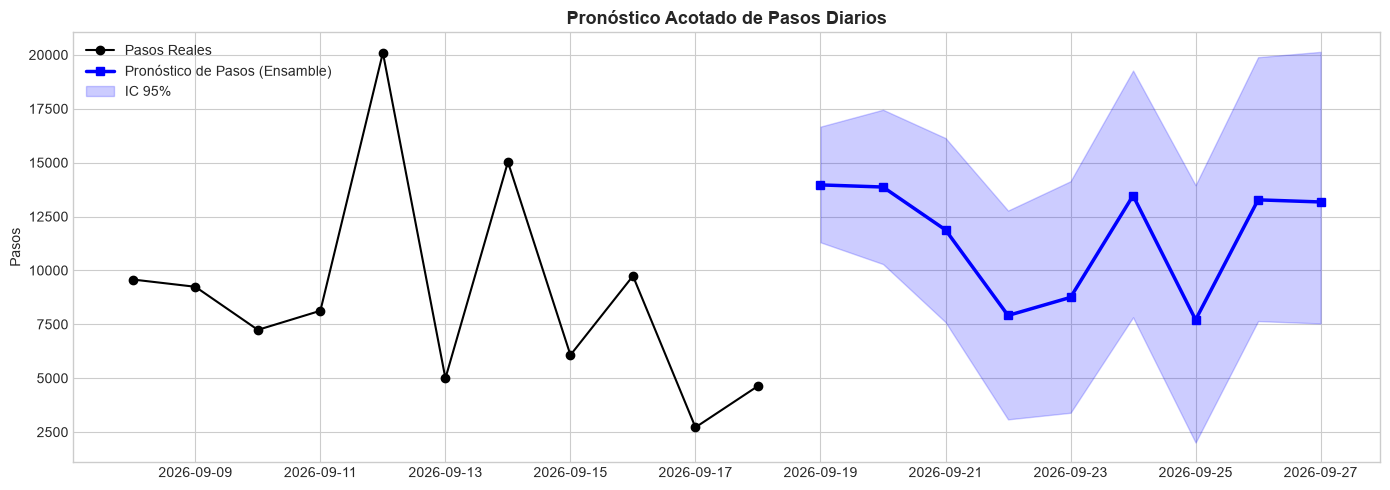

In [2]:
# Pronóstico de pasos
horizon = 9
bounds = compute_physiological_bounds(df["total_steps"], "total_steps")
print(f"🩺 Umbrales de Pasos: {bounds} pasos")

ens = EnsembleBiometricForecaster(bounds=bounds).fit(df, "total_steps")
pred = ens.predict(periods=horizon)

fut_mask = pred["ds"] > df["calendar_date"].max()
fut_dates = pred.loc[fut_mask, "ds"]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df["calendar_date"], df["total_steps"], "ko-", label="Pasos Reales")
ax.plot(fut_dates, pred.loc[fut_mask, "yhat"], "b-s", linewidth=2.5, label="Pronóstico de Pasos (Ensamble)")
ax.fill_between(fut_dates, pred.loc[fut_mask, "yhat_lower"], pred.loc[fut_mask, "yhat_upper"], color="blue", alpha=0.2, label="IC 95%")

ax.set_title("Pronóstico Acotado de Pasos Diarios", fontweight="bold", fontsize=13)
ax.set_ylabel("Pasos")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


## 💡 Conclusión y Hallazgos
- Las proyecciones de volumen de pasos respetan el límite físico ($\ge 0$), evitando caídas irreales en fines de semana o días de descanso.
